In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

2026-04-01 21:32:50.293134: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775079170.710396      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775079170.820265      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775079171.754747      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775079171.754794      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775079171.754798      23 computation_placer.cc:177] computation placer alr

In [2]:
augmented_dir = "/kaggle/input/datasets/marjukibnabelayet/cse438-group4/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Augmented_Dataset"

original_dir = "/kaggle/input/datasets/marjukibnabelayet/cse438-group4/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Original_Dataset"

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
SEED = 42

AUTOTUNE = tf.data.AUTOTUNE

In [4]:
class_names = sorted([
    d for d in os.listdir(augmented_dir)
    if os.path.isdir(os.path.join(augmented_dir, d))
])

num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['Healthy_Leaf', 'Leaf_Rot', 'Leaf_Spot']
Number of classes: 3


In [5]:
def get_image_paths_and_labels(data_dir, class_names):
    file_paths = []
    labels = []

    valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

    for idx, class_name in enumerate(class_names):
        class_path = os.path.join(data_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):
            if file_name.lower().endswith(valid_ext):
                file_paths.append(os.path.join(class_path, file_name))
                labels.append(idx)

    return file_paths, labels

train_paths, train_labels = get_image_paths_and_labels(augmented_dir, class_names)
original_paths, original_labels = get_image_paths_and_labels(original_dir, class_names)

print("Training images from Augmented_Dataset:", len(train_paths))
print("Images from Original_Dataset:", len(original_paths))

Training images from Augmented_Dataset: 10185
Images from Original_Dataset: 2037


In [6]:
val_paths, test_paths, val_labels, test_labels = train_test_split(
    original_paths,
    original_labels,
    test_size=0.5,
    random_state=SEED,
    stratify=original_labels
)

print("Validation images:", len(val_paths))
print("Test images:", len(test_paths))

Validation images: 1018
Test images: 1019


In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

def augment_image(image, label):
    image = data_augmentation(image, training=True)
    return image, label

I0000 00:00:1775079213.223748      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775079213.230024      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [8]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def create_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(augment_image, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

In [9]:
train_ds = create_dataset(train_paths, train_labels, training=True)
val_ds = create_dataset(val_paths, val_labels, training=False)
test_ds = create_dataset(test_paths, test_labels, training=False)

print("Datasets created successfully.")

Datasets created successfully.


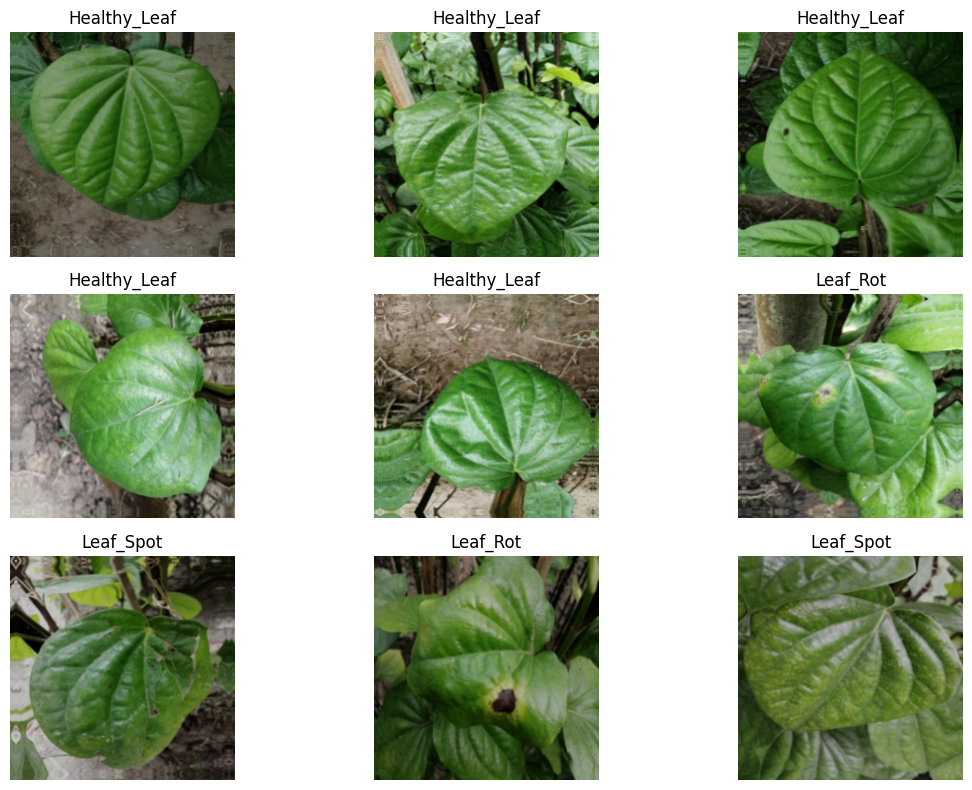

In [10]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(tf.cast(images[i], tf.uint8))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
input_layer = layers.Input(shape=(224, 224, 3), name="input_image")

# Branch 1: VGG16
x1 = layers.Lambda(vgg16_preprocess, name="vgg16_preprocess")(input_layer)
vgg16_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
vgg16_base.trainable = False
x1 = vgg16_base(x1, training=False)
x1 = layers.GlobalAveragePooling2D()(x1)
x1 = layers.Dense(256, activation="relu")(x1)
x1 = layers.Dropout(0.4)(x1)

# Branch 2: ResNet50
x2 = layers.Lambda(resnet_preprocess, name="resnet_preprocess")(input_layer)
resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
resnet_base.trainable = False
x2 = resnet_base(x2, training=False)
x2 = layers.GlobalAveragePooling2D()(x2)
x2 = layers.Dense(256, activation="relu")(x2)
x2 = layers.Dropout(0.4)(x2)

# Late Fusion
fusion = layers.Concatenate(name="late_fusion_concat")([x1, x2])
fusion = layers.Dense(512, activation="relu")(fusion)
fusion = layers.Dropout(0.5)(fusion)

output_layer = layers.Dense(num_classes, activation="softmax", name="output")(fusion)

model = Model(
    inputs=input_layer,
    outputs=output_layer,
    name="LateFusion_VGG16_ResNet50"
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "LateFusion_VGG16_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_preprocess    │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet_preprocess   │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ vgg16_preprocess… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ resnet_preproces… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ late_fusion_concat  │ (None, 512)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    262,656 │ late_fusion_conc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │      1,539 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 39,222,467 (149.62 MB)

 Trainable params: 920,067 (3.51 MB)

 Non-trainable params: 38,302,400 (146.11 MB)

In [13]:
callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        "late_fusion_pipeline4_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20


I0000 00:00:1775079228.915740      70 service.cc:152] XLA service 0x7ed0b001dff0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775079228.915784      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775079228.915789      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775079231.489933      70 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775079249.968378      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.6045 - loss: 1.2324
Epoch 1: val_accuracy improved from -inf to 0.86346, saving model to late_fusion_pipeline4_best.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 210s 569ms/step - accuracy: 0.6047 - loss: 1.2312 - val_accuracy: 0.8635 - val_loss: 0.3614 - learning_rate: 1.0000e-04
Epoch 2/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.8148 - loss: 0.4846
Epoch 2: val_accuracy improved from 0.86346 to 0.89096, saving model to late_fusion_pipeline4_best.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 145s 453ms/step - accuracy: 0.8148 - loss: 0.4845 - val_accuracy: 0.8910 - val_loss: 0.3152 - learning_rate: 1.0000e-04
Epoch 3/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.8479 - loss: 0.3949
Epoch 3: val_accuracy improved from 0.89096 to 0.90373, saving model to late_fusion_pipeline4_best.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 145s 455ms/step - accuracy: 0.8480 - loss: 0.3948 - val_accuracy: 0.9037 - val_loss: 0.2552 - learning_rate:

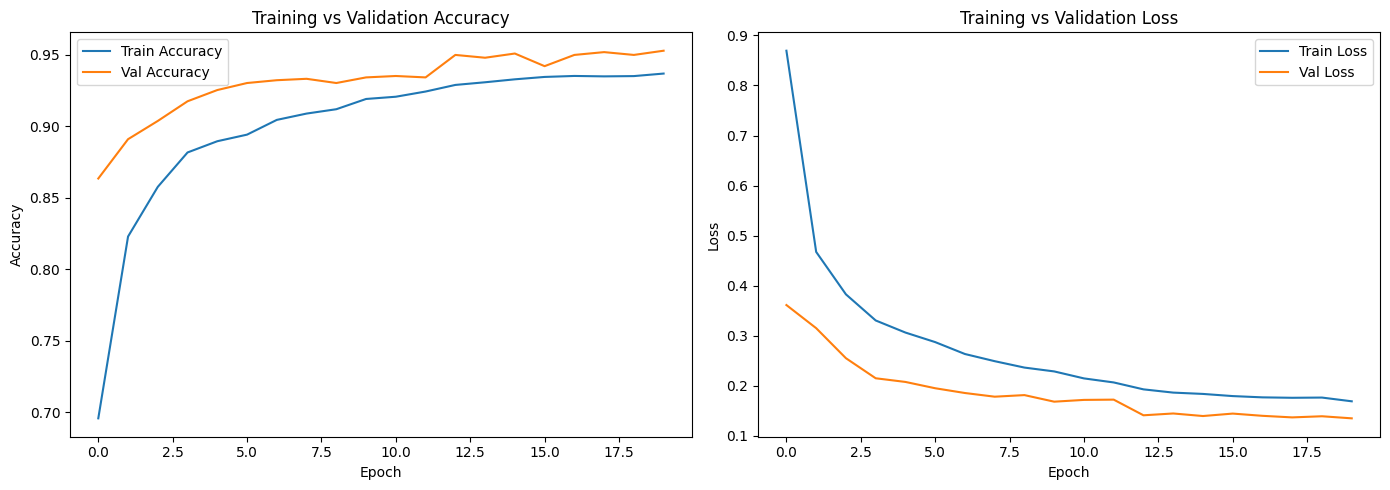

In [15]:
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 760ms/step - accuracy: 0.9379 - loss: 0.1429
Test Loss: 0.1350422203540802
Test Accuracy: 0.9479882121086121


In [17]:
y_true = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 392ms/step
              precision    recall  f1-score   support

Healthy_Leaf       0.96      0.97      0.97       540
    Leaf_Rot       0.97      0.81      0.88       135
   Leaf_Spot       0.92      0.97      0.94       344

    accuracy                           0.95      1019
   macro avg       0.95      0.92      0.93      1019
weighted avg       0.95      0.95      0.95      1019



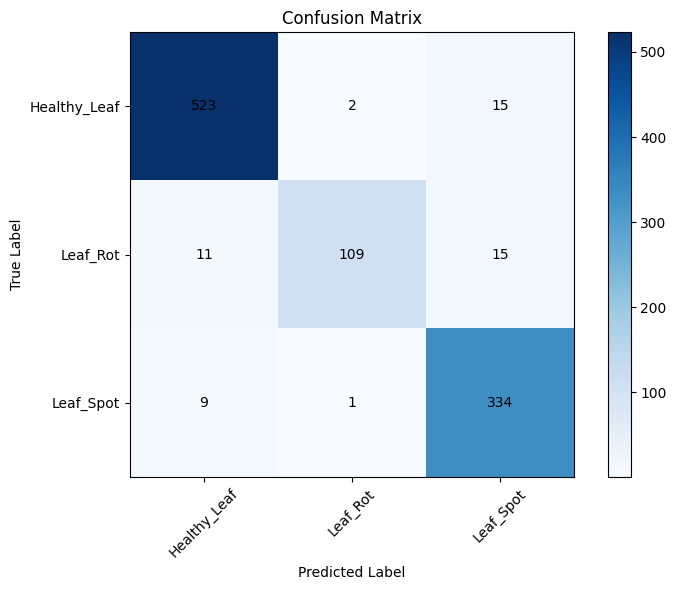

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [19]:
model.save("late_fusion_pipeline4_final.keras")
print("Model saved successfully.")

Model saved successfully.
